### Imports

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

### 1)

In [38]:
def display_image(image, title=None, size=None, conversion=cv2.COLOR_BGR2RGB):
    """Display image in notebook"""
    # Converts from one colour space to the other. 
    # OpenCV uses BGR array instead of RGB. 
    # Default is to convert BGR to RGB using.
    if conversion is not None:
        image = cv2.cvtColor(image, conversion)
    
    # If size is provided, set figsize accordingly.
    if size is not None:
        aspect_ratio = image.shape[0]/image.shape[1]
        plt.figure(figsize=(size * aspect_ratio,size))
    
    # Show the image
    plt.imshow(image)

    # Remove the ticks.
    plt.xticks([]), plt.yticks([])

    # If a title is provided, show it.
    if title is not None:
        plt.title(title)

    plt.show()

In [52]:
def white_patch(img, percentile=99):
    # Split channels.
    b, g, r = cv2.split(img)

    # Get max.
    b_max, g_max, r_max = np.max(b), np.max(g), np.max(r)
    #b_max, g_max, r_max = np.max(img, axis=(0, 1)

    # Check if all 255.
    if all(x == 255 for x in [b_max, g_max, r_max]):
        b_max, g_max, r_max = np.percentile(img, percentile, axis=(0, 1))

    # Compute.
    b = (255.0 / b_max)* b.astype(np.float32)
    g = (255.0 / g_max)* g.astype(np.float32)
    r = (255.0 / r_max)* r.astype(np.float32)

    # Merge.
    return cv2.merge((b, g, r)).astype(np.uint8)

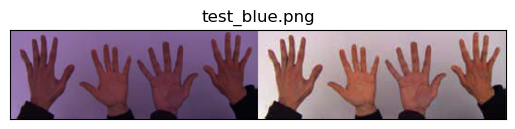

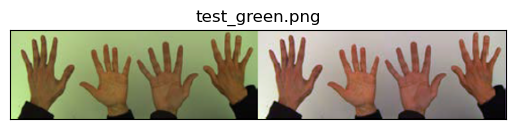

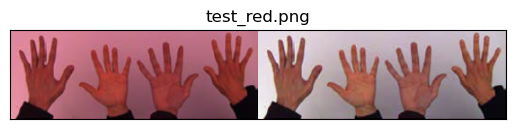

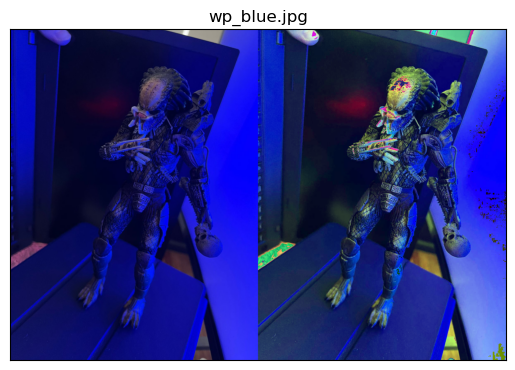

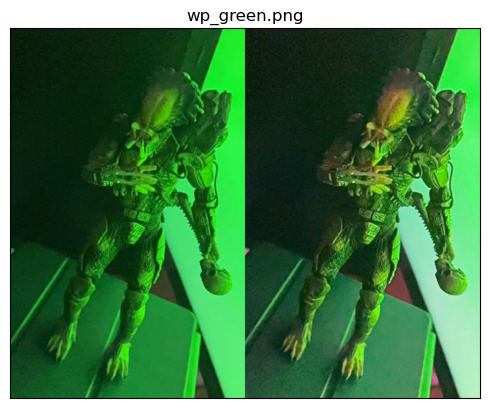

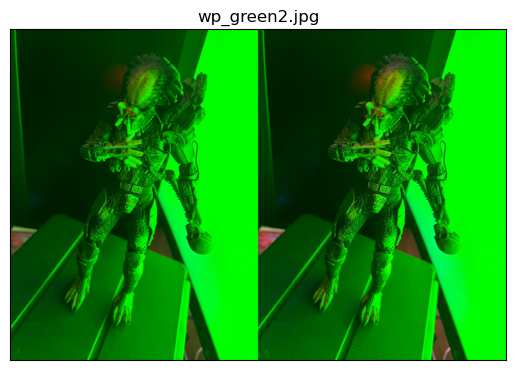

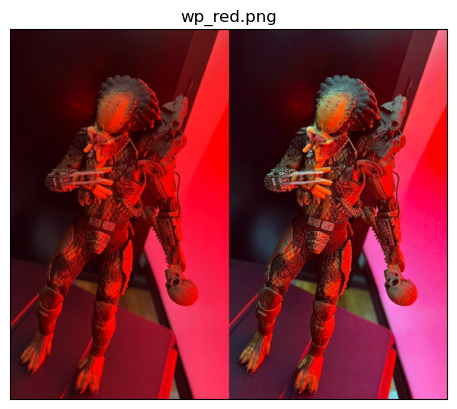

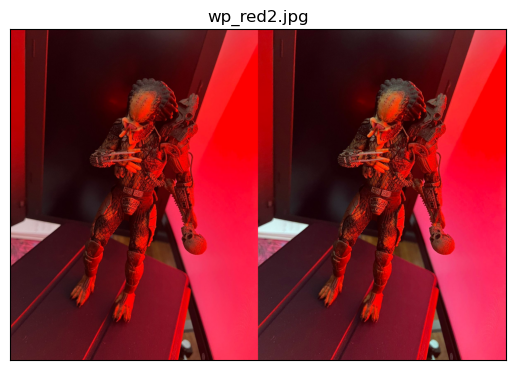

In [61]:
for img_path in (Path.cwd() / 'white_patch').glob('*'):
    # Read
    img = cv2.imread(img_path)

    # White patch
    wp_img = white_patch(img)

    # Plot
    display_image(np.hstack((img, wp_img)), title=Path(img_path).name)

In the case of the hands pictures, no obvious blemishes can be spotted. Also, the algorithm seems to give similar results for all three of them

In the case of the figurine, the blue picture stands out. The algorithm introduced a lot of artifacts, mostly on the figurine's head and on the right all. The other images don't show any obvious artifacts

### 2)

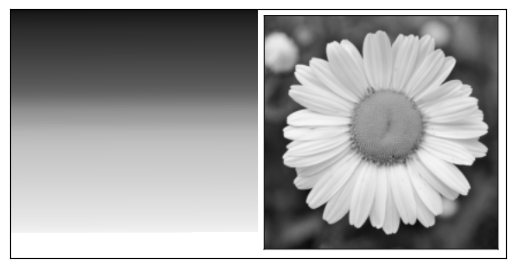

In [63]:
# Read
img1 = cv2.imread('img1_tp.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('img2_tp.png', cv2.IMREAD_GRAYSCALE)

display_image(np.hstack((img1, img2)))

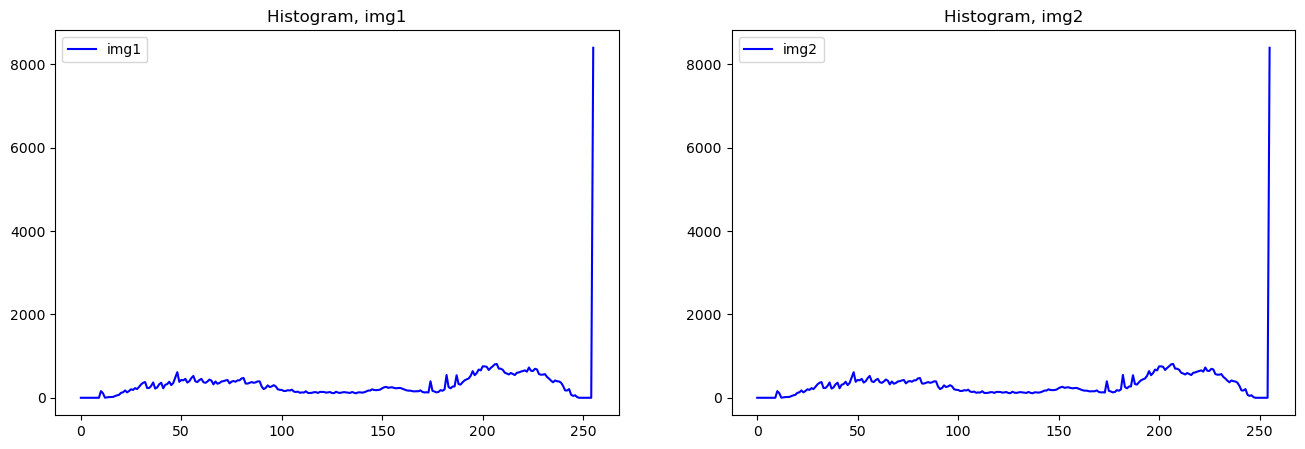

In [77]:
# Histograms.
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

hist1 = cv2.calcHist([img1], channels=[0], mask=None, histSize=[256] , ranges=[0, 256])
axs[0].plot(hist1, color = 'b', label="img1")
axs[0].set_title('Histogram, img1')
axs[0].legend()

hist2 = cv2.calcHist([img2], channels=[0], mask=None, histSize=[256] , ranges=[0, 256])
axs[1].plot(hist2, color = 'b', label="img2")
axs[1].set_title('Histogram, img2')
axs[1].legend()
plt.show()

We see that both images present the exact same histogram. Since histograms don't have any spatial information from the image itself, they don't tend to be exactly useful for classification, object detection or segmentation algorithms. This example is an extreme one, where completely different images have the same exact histogram, but it illustrates the idea.